# 01 – Data loading and validation

Replication of Jiwa, M. W. & Gottlieb, J. (2026). *Modeling information demand in the framework of probabilistic reasoning*. Communications Psychology, 4, 31. Original data and code: https://osf.io/rsydx

In [1]:
# --- Settings ---
GITHUB_USER   = "Ash6389"
GITHUB_REPO   = "reproduce-Jiwa-Gottlieb-2026"
GITHUB_BRANCH = "main"

# --- Clone the private repository into the Colab runtime ---
import subprocess
from pathlib import Path
from google.colab import userdata

REPO_DIR = Path("/content") / GITHUB_REPO
token = userdata.get("GITHUB_TOKEN")
url = f"https://{token}@github.com/{GITHUB_USER}/{GITHUB_REPO}.git"

if (REPO_DIR / ".git").exists():   # already cloned in this session: pull latest
    subprocess.run(["git", "-C", str(REPO_DIR), "pull", "-q", url, GITHUB_BRANCH], check=False)
else:
    r = subprocess.run(["git", "clone", "-q", "--depth", "1", "-b", GITHUB_BRANCH, url, str(REPO_DIR)],
                       capture_output=True, text=True)
    if r.returncode != 0:
        raise RuntimeError(r.stderr.replace(token, "***"))

print(sorted(p.name for p in REPO_DIR.iterdir()))

['.git', '.gitignore', 'Data', 'Models', 'README.md', 'notebooks', 'src']


In [2]:
%pip install -q pyreadr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.4/829.4 kB 12.8 MB/s eta 0:00:00


In [3]:
import pyreadr
import pandas as pd
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)

DATA_FILES = {
    "exp1":   "Data/NoninstrumentalInfoSeeking/nonInstrumentalInfoData.RData",
    "exp1_q": "Data/NoninstrumentalInfoSeeking/nonInstrumentalInfoQuestionnaireData.Rdata",
    "exp2":   "Data/InstrumentalInfoSeeking/InstrumentalInfoData.Rdata",
    "exp2_q": "Data/InstrumentalInfoSeeking/InstrumentalInfoQuestionnaireData.Rdata",
    "exp3":   "Data/RiskyChoice/infoRiskTaskData.RData",
    "exp3_q": "Data/RiskyChoice/infoRiskQuestionnaireData.Rdata",
}

raw = {key: pyreadr.read_r(str(REPO_DIR / path)) for key, path in DATA_FILES.items()}

for key, objs in raw.items():
    for name, df in objs.items():
        print(f"{key:7s} {name:13s} {df.shape[0]:6d} rows x {df.shape[1]:2d} cols")

exp1    allTrials       2700 rows x 15 cols
exp1    demographics      50 rows x  3 cols
exp1_q  qScores           50 rows x  8 cols
exp2    allTrials       3600 rows x 11 cols
exp2    demographics      50 rows x  3 cols
exp2_q  qScores           50 rows x  8 cols
exp3    infoTrials     10800 rows x 11 cols
exp3    riskTrials     10800 rows x 10 cols
exp3    demographics     150 rows x  3 cols
exp3_q  qScores          150 rows x  8 cols


In [4]:
raw["exp2"]["allTrials"].head(10)

,ID,stan_ID,bid,prior,abs_prior,frame,stake,errUnc,IV,gainFrame,lossFrame
0,4.0,1,0.85,0.5,0.5,G,2.0,0.5,1.0,1.0,0.0
1,4.0,1,0.80,0.4,0.4,G,2.0,0.4,0.8,1.0,0.0
2,4.0,1,0.50,0.3,0.3,G,2.0,0.3,0.6,1.0,0.0
3,4.0,1,0.40,0.2,0.2,G,2.0,0.2,0.4,1.0,0.0
4,4.0,1,0.08,0.9,0.9,G,2.0,0.1,0.2,1.0,0.0
5,4.0,1,0.94,0.5,0.5,G,2.0,0.5,1.0,1.0,0.0
6,4.0,1,0.20,0.8,0.8,G,2.0,0.2,0.4,1.0,0.0
7,4.0,1,0.40,0.3,0.3,G,2.0,0.3,0.6,1.0,0.0
8,4.0,1,0.52,0.2,0.2,G,2.0,0.2,0.4,1.0,0.0
9,4.0,1,0.46,0.7,0.7,G,2.0,0.3,0.6,1.0,0.0


## 2. Tidy trial-level data

All four tasks are converted to the same long format (one row per trial), with a common subject index, recomputed task variables, and the response bounds of each trial.

In [6]:
import numpy as np

LOTTERY_MAG = 5.0   # lottery outcome is +/- $5 in all experiments
STAKE = 2.0         # Exp 2/3: instrumental reward for a correct guess

def misclass_rate(p):
    """Probability of a wrong guess without information, min(p, 1 - p) (= errUnc)."""
    p = np.asarray(p, float)
    return np.round(np.minimum(p, 1 - p), 10)

def entropy_bits(p):
    """Shannon entropy in bits (0-1, maximal at p = 0.5)."""
    p = np.clip(np.asarray(p, float), 1e-12, 1 - 1e-12)
    return -(p * np.log2(p) + (1 - p) * np.log2(1 - p))

def tidy_common(t, exp, task):
    """Columns shared by all tasks."""
    out = pd.DataFrame({
        "exp": exp,
        "task": task,
        "orig_id": t["ID"].astype(int).to_numpy(),
        "stan_id": t["stan_ID"].astype(int).to_numpy(),
    })
    out["subj"] = out["stan_id"] - 1                        # 0-based subject index
    # Row order within subject follows presentation order (G/L blocks alternate)
    out["trial"] = out.groupby("subj").cumcount()
    out["frame"] = t["frame"].astype(str).to_numpy()
    out["block"] = (out.groupby("subj")["frame"]
                       .transform(lambda f: (f != f.shift()).cumsum()).astype(int))
    out["is_loss"] = (out["frame"] == "L").astype(int)
    out["valence"] = np.where(out["is_loss"] == 1, -1, 1)
    # prior has floating-point residue (e.g. 0.7000000000000001) -> round to 0.1
    out["p"] = np.round(t["abs_prior"].to_numpy(float), 1)   # P(outcome item)
    out["p_signed"] = out["valence"] * out["p"]                # negative on loss trials
    out["misclass"] = misclass_rate(out["p"])
    out["entropy"] = entropy_bits(out["p"])
    out["ev"] = out["p_signed"] * LOTTERY_MAG                  # expected value (hedonic term)
    return out

def add_bounds(out, lo, hi, tol=1e-9):
    """Response bounds; cens = -1 at lower bound, +1 at (or beyond) upper bound, 0 inside."""
    out["y_lo"] = np.broadcast_to(lo, len(out)).astype(float)
    out["y_hi"] = np.broadcast_to(hi, len(out)).astype(float)
    y, ylo, yhi = out["y"].to_numpy(float), out["y_lo"].to_numpy(), out["y_hi"].to_numpy()
    out["out_of_range"] = (y < ylo - tol) | (y > yhi + tol)
    out["cens"] = np.select([y <= ylo + tol, y >= yhi - tol], [-1, 1], 0).astype(int)
    return out

In [7]:
def tidy_e1(t):
    out = tidy_common(t, "e1", "curiosity")
    out["y"] = t["rating"].to_numpy(float)              # raw curiosity rating, 0-100
    out = add_bounds(out, 0.0, 100.0)
    # The original models use within-subject z-scores, truncated at the z-scale bounds
    out["y_z"] = t["rating_z"].to_numpy(float)
    out["z_lo"] = t["value_min"].to_numpy(float)
    out["z_hi"] = t["value_max"].to_numpy(float)
    out["misclass_z"] = t["errUnc_z"].to_numpy(float)
    return out

def tidy_info(t, exp):
    out = tidy_common(t, exp, "info_bid")
    out["y"] = t["bid"].to_numpy(float)                 # bid, $0-2
    out["stake"] = t["stake"].to_numpy(float)
    out["iv"] = out["misclass"] * out["stake"]          # normative bid
    return add_bounds(out, 0.0, 2.0)

def tidy_risk(t):
    out = tidy_common(t, "e3", "risk_threshold")
    out["y"] = t["threshold"].to_numpy(float)           # minimum acceptable sure amount
    out["reward"] = t["reward"].to_numpy(float)
    out["ev"] = out["p_signed"] * out["reward"]         # normative threshold = EV
    lo = np.where(out["is_loss"] == 1, -5.0, 0.0)      # slider: $0 -> $5 (gain), -$5 -> $0 (loss)
    hi = np.where(out["is_loss"] == 1, 0.0, 5.0)
    return add_bounds(out, lo, hi)

trials = {
    "e1":      tidy_e1(raw["exp1"]["allTrials"]),
    "e2":      tidy_info(raw["exp2"]["allTrials"], "e2"),
    "e3_info": tidy_info(raw["exp3"]["infoTrials"], "e3"),
    "e3_risk": tidy_risk(raw["exp3"]["riskTrials"]),
}

for k, df in trials.items():
    n = df["subj"].nunique()
    print(f"{k:8s} {n:3d} subjects x {len(df) // n} trials = {len(df):5d} rows, {df.shape[1]} columns")

e1        50 subjects x 54 trials =  2700 rows, 24 columns
e2        50 subjects x 72 trials =  3600 rows, 22 columns
e3_info  150 subjects x 72 trials = 10800 rows, 22 columns
e3_risk  150 subjects x 72 trials = 10800 rows, 21 columns


In [9]:
trials["e2"].head(10)

,exp,task,orig_id,stan_id,subj,trial,frame,block,is_loss,valence,p,p_signed,misclass,entropy,ev,y,stake,iv,y_lo,y_hi,out_of_range,cens
0,e2,info_bid,4,1,0,0,G,1,0,1,0.5,0.5,0.5,1.000000,2.5,0.85,2.0,1.0,0.0,2.0,False,0
1,e2,info_bid,4,1,0,1,G,1,0,1,0.4,0.4,0.4,0.970951,2.0,0.80,2.0,0.8,0.0,2.0,False,0
2,e2,info_bid,4,1,0,2,G,1,0,1,0.3,0.3,0.3,0.881291,1.5,0.50,2.0,0.6,0.0,2.0,False,0
3,e2,info_bid,4,1,0,3,G,1,0,1,0.2,0.2,0.2,0.721928,1.0,0.40,2.0,0.4,0.0,2.0,False,0
4,e2,info_bid,4,1,0,4,G,1,0,1,0.9,0.9,0.1,0.468996,4.5,0.08,2.0,0.2,0.0,2.0,False,0
5,e2,info_bid,4,1,0,5,G,1,0,1,0.5,0.5,0.5,1.000000,2.5,0.94,2.0,1.0,0.0,2.0,False,0
6,e2,info_bid,4,1,0,6,G,1,0,1,0.8,0.8,0.2,0.721928,4.0,0.20,2.0,0.4,0.0,2.0,False,0
7,e2,info_bid,4,1,0,7,G,1,0,1,0.3,0.3,0.3,0.881291,1.5,0.40,2.0,0.6,0.0,2.0,False,0
8,e2,info_bid,4,1,0,8,G,1,0,1,0.2,0.2,0.2,0.721928,1.0,0.52,2.0,0.4,0.0,2.0,False,0
9,e2,info_bid,4,1,0,9,G,1,0,1,0.7,0.7,0.3,0.881291,3.5,0.46,2.0,0.6,0.0,2.0,False,0


In [11]:
bounds = pd.DataFrame({
    k: {"% at lower bound": 100 * (df["cens"] == -1).mean(),
        "% at upper bound": 100 * (df["cens"] == 1).mean(),
        "n out of range":   df["out_of_range"].sum()}
    for k, df in trials.items()
}).T.round(1).astype({"n out of range": int})
bounds

,% at lower bound,% at upper bound,n out of range
e1,5.0,2.7,0
e2,8.5,1.4,0
e3_info,8.0,0.1,0
e3_risk,1.9,4.0,1


## 3. Subject table

One row per subject with demographics and questionnaire scores, aligned on the same `subj` index as the trial data.

In [12]:
QUEST_COLS = ["FiveDC_ST", "FiveDC_TS", "NFC", "BigFive_EV", "PHQ_Anx", "PHQ_Dep", "PHQ_total"]

def tidy_subjects(demo, q, trials_df):
    """One row per subject: index columns, demographics, questionnaire scores (raw and z-scored).

    stan_ID is the order of first appearance in the trial file, not the rank of the
    original ID, so subjects are never aligned by sorting on ID:
      - demographics are merged on the original ID;
      - qScores$ID is the condensed 1..N index (same as stan_ID) and is merged on stan_id.
    """
    s = trials_df[["subj", "stan_id", "orig_id"]].drop_duplicates().sort_values("subj")
    d = (demo.assign(orig_id=demo["ID"].astype(int))
             .rename(columns={"Gender": "gender", "Age": "age"}))
    s = s.merge(d[["orig_id", "gender", "age"]], on="orig_id", how="left", validate="1:1")
    qq = q.rename(columns={"ID": "stan_id"}).astype({"stan_id": int})
    s = s.merge(qq, on="stan_id", how="left", validate="1:1")
    s["gender"] = s["gender"].astype(str)
    for c in QUEST_COLS:                 # z-scored within experiment
        s[c + "_z"] = (s[c] - s[c].mean()) / s[c].std(ddof=1)
    return s.reset_index(drop=True)

subjects = {
    "e1": tidy_subjects(raw["exp1"]["demographics"], raw["exp1_q"]["qScores"], trials["e1"]),
    "e2": tidy_subjects(raw["exp2"]["demographics"], raw["exp2_q"]["qScores"], trials["e2"]),
    "e3": tidy_subjects(raw["exp3"]["demographics"], raw["exp3_q"]["qScores"], trials["e3_info"]),
}

# Sample description reported in the paper (Methods)
PAPER = {
    "e1": dict(N=50,  F=22, M=27, O=1, age_mean=31.96, age_sd=5.09, age_min=21, age_max=40),
    "e2": dict(N=50,  F=20, M=30, O=0, age_mean=30.78, age_sd=5.95, age_min=20, age_max=40),
    "e3": dict(N=150, F=70, M=77, O=3, age_mean=30.99, age_sd=5.43, age_min=18, age_max=40),
}

def describe_sample(s):
    g = s["gender"].value_counts()
    return dict(N=len(s), F=g.get("F", 0), M=g.get("M", 0), O=g.get("O", 0),
                age_mean=round(s["age"].mean(), 2), age_sd=round(s["age"].std(ddof=1), 2),
                age_min=int(s["age"].min()), age_max=int(s["age"].max()))

sample = pd.concat({e: pd.DataFrame([describe_sample(s), PAPER[e]], index=["data", "paper"])
                    for e, s in subjects.items()})
sample

N   F   M  O  age_mean  age_sd  age_min  age_max
e1 data    50  22  27  1     31.96    5.09       21       40
   paper   50  22  27  1     31.96    5.09       21       40
e2 data    50  20  30  0     30.78    5.95       20       40
   paper   50  20  30  0     30.78    5.95       20       40
e3 data   150  70  77  3     30.99    5.43       18       40
   paper  150  70  77  3     30.99    5.43       18       40

In [13]:
subjects["e3"].head()

,subj,stan_id,orig_id,gender,age,FiveDC_ST,FiveDC_TS,NFC,BigFive_EV,PHQ_Anx,PHQ_Dep,PHQ_total,FiveDC_ST_z,FiveDC_TS_z,NFC_z,BigFive_EV_z,PHQ_Anx_z,PHQ_Dep_z,PHQ_total_z
0,0,1,2,F,36.0,2.4,2.0,-3.0,12.0,5,4,9,-1.097370,-0.845627,-0.294654,-1.193724,1.371858,1.217603,1.389983
1,1,2,4,M,38.0,7.0,5.6,60.0,34.0,0,0,0,1.832914,1.646941,1.803676,1.342844,-1.187579,-0.969708,-1.159579
2,2,3,5,F,31.0,5.0,2.2,51.0,11.0,2,1,3,0.558877,-0.707151,1.503915,-1.309023,-0.163804,-0.422880,-0.309725
3,3,4,6,F,30.0,3.0,4.8,5.0,28.0,4,3,7,-0.715159,1.093037,-0.028200,0.651052,0.859971,0.670775,0.823414
4,4,5,7,M,35.0,5.6,1.8,39.0,23.0,0,0,0,0.941088,-0.984103,1.104233,0.074560,-1.187579,-0.969708,-1.159579


## 4. Validation

Derived variables are recomputed and compared with the original columns, and the sample is compared with the description in the paper.

In [14]:
def validate(trials, subjects, raw):
    """Recompute derived variables and compare with the original columns and the paper."""
    rows = []
    def check(name, ok, detail=""):
        rows.append(dict(check=name, ok=bool(ok), detail=detail))

    src = {"e1": raw["exp1"]["allTrials"], "e2": raw["exp2"]["allTrials"],
           "e3_info": raw["exp3"]["infoTrials"], "e3_risk": raw["exp3"]["riskTrials"]}
    task_exp = {"e1": "e1", "e2": "e2", "e3_info": "e3", "e3_risk": "e3"}

    for k, df in trials.items():
        r = src[k]
        n = df["subj"].nunique()
        tps = df.groupby("subj").size()
        reps = df.groupby(["subj", "p_signed"]).size()
        check(f"{k}: N matches paper", n == PAPER[task_exp[k]]["N"], f"N={n}")
        check(f"{k}: subj is 0..N-1, rows contiguous by subject",
              (np.sort(df["subj"].unique()) == np.arange(n)).all() and df["subj"].is_monotonic_increasing)
        check(f"{k}: equal trials per subject", tps.nunique() == 1, f"{tps.iloc[0]} trials/subject")
        check(f"{k}: 18 lotteries (9 p x gain/loss)", df["p_signed"].nunique() == 18)
        check(f"{k}: equal repetitions per lottery", reps.nunique() == 1, f"{reps.iloc[0]} per lottery")
        check(f"{k}: p == abs_prior", np.allclose(df["p"], r["abs_prior"]))
        check(f"{k}: frame matches sign of prior", ((r["prior"] < 0) == (df["frame"] == "L")).all())
        if "errUnc" in r:
            check(f"{k}: misclass == errUnc", np.allclose(df["misclass"], r["errUnc"]))
        if "IV" in r:
            check(f"{k}: iv == IV", np.allclose(df["iv"], r["IV"]))
        if "EV" in r:
            check(f"{k}: ev == EV", np.allclose(df["ev"], r["EV"]))

    e1 = trials["e1"]
    g = e1.groupby("subj")["y"]
    m, sd = g.transform("mean"), g.transform("std")
    check("e1: within-subject z == rating_z", np.allclose((e1["y"] - m) / sd, e1["y_z"]))
    check("e1: z-scale bounds == value_min/max",
          np.allclose((100 - m) / sd, e1["z_hi"]) and np.allclose((0 - m) / sd, e1["z_lo"]))

    a = trials["e3_info"].groupby("subj")["orig_id"].first()
    b = trials["e3_risk"].groupby("subj")["orig_id"].first()
    check("e3: same subjects and subj index in both tasks", a.equals(b))

    for e, s in subjects.items():
        check(f"{e}: sample description matches paper", describe_sample(s) == PAPER[e])
        check(f"{e}: no missing demographics/questionnaires", s[["age", *QUEST_COLS]].notna().all().all())

    res = pd.DataFrame(rows)
    print(f"{len(res)} checks: {res['ok'].sum()} passed, {(~res['ok']).sum()} failed")
    return res

checks = validate(trials, subjects, raw)
checks

43 checks: 43 passed, 0 failed


,check,ok,detail
0,e1: N matches paper,True,N=50
1,"e1: subj is 0..N-1, rows contiguous by subject",True,
2,e1: equal trials per subject,True,54 trials/subject
3,e1: 18 lotteries (9 p x gain/loss),True,
4,e1: equal repetitions per lottery,True,3 per lottery
5,e1: p == abs_prior,True,
6,e1: frame matches sign of prior,True,
7,e1: misclass == errUnc,True,
8,e2: N matches paper,True,N=50
9,"e2: subj is 0..N-1, rows contiguous by subject",True,


## 5. Data notes

Checks for features of the data that deviate from the paper's description or that matter for the modelling.

In [15]:
e1 = trials["e1"]
block_sizes = sorted(e1.groupby(["subj", "block"]).size().unique().tolist())
print("Exp 1 trials per subject:", e1.groupby("subj").size().iloc[0], "| trials per block:", block_sizes)

has_catch = any(df["p"].isin([0, 1]).any() for df in trials.values())
print("Catch trials (p = 0 or 1) in the files:", has_catch)

for k in ["e1", "e2", "e3_info"]:
    m = trials[k][["stan_id", "orig_id"]].drop_duplicates()
    n_diff = (m["orig_id"].rank().astype(int) != m["stan_id"]).sum()
    print(f"{k}: subjects whose stan_ID differs from the rank of their original ID: {n_diff}")

oor = trials["e3_risk"].loc[trials["e3_risk"]["out_of_range"],
                            ["subj", "orig_id", "frame", "p", "y", "y_lo", "y_hi", "cens"]]
oor

Exp 1 trials per subject: 54 | trials per block: [13, 14]
Catch trials (p = 0 or 1) in the files: False
e1: subjects whose stan_ID differs from the rank of their original ID: 2
e2: subjects whose stan_ID differs from the rank of their original ID: 0
e3_info: subjects whose stan_ID differs from the rank of their original ID: 6


,subj,orig_id,frame,p,y,y_lo,y_hi,cens
7184,99,131,L,0.1,0.075,-5.0,0.0,1


**Notes on the data**

- **Exp 1 has 54 trials per participant** (13–14 per block, 3 repetitions per lottery) rather than the 72 described in Methods (18 per block); Exp 2/3 have 72. The data are used as provided; to be clarified with the authors.
- **No catch trials** (p = 0 or 1) are included in the data files.
- **Subject alignment.** `stan_ID` is the order of appearance, not the rank of the original ID (2 subjects differ in Exp 1, 6 in Exp 3). All merges use `subj`.
- **One out-of-range response** in the risky-choice task (loss trial, threshold +$0.075; slider range −$5 to $0). Flagged and treated as lying at the upper bound.
- **Boundary responses are point masses** (see section 2: about 8% of bids are exactly $0). The original models use a truncated normal, and not consistently:
  - Exp 1 `NI_MM` and `NI_PR`: truncated normal in both the likelihood and `log_lik`; the single-PWF variant `NI_PR_oneFunc`: untruncated in both.
  - All Exp 2/3 models (including risky choice): untruncated normal in the `model` block, but truncated normal in the `log_lik` used for WAIC.

  Some WAIC comparisons are therefore made between different likelihoods, and WAIC does not always correspond to the fitted model. The `cens` column is used for a censored likelihood in the models that follow.

## 6. Data panels (cf. Figs. 1D, 2D, 3D–E)

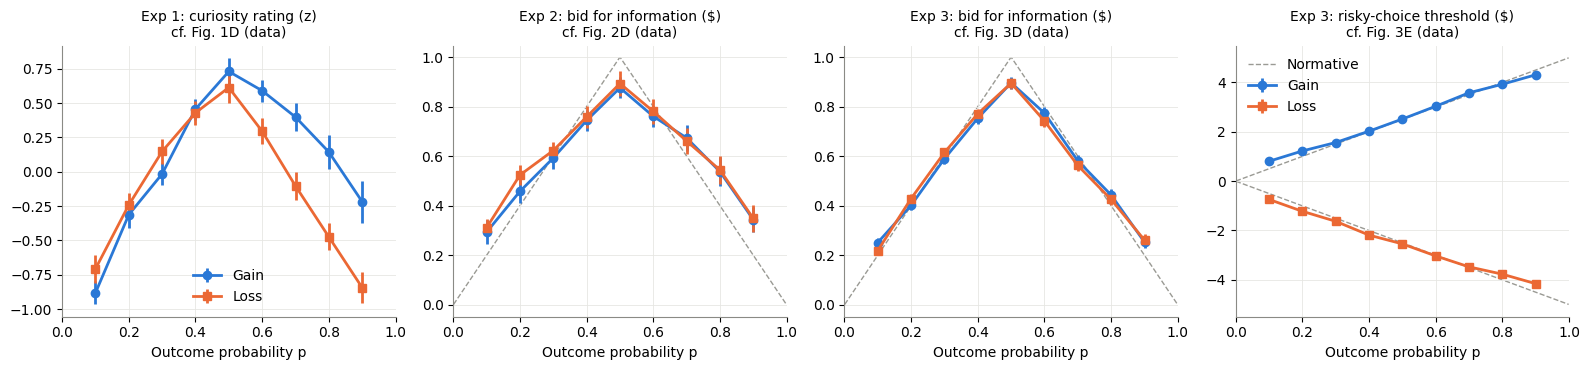

In [16]:
import matplotlib.pyplot as plt

GAIN, LOSS, NORM = "#2a78d6", "#eb6834", "#9a9a94"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e6e6e3", "grid.linewidth": 0.6,
                     "axes.edgecolor": "#8a8a85", "font.size": 10})

def mean_sem(df, col):
    """Average within subject first, then mean and SEM across subjects (as in the paper)."""
    s = df.groupby(["frame", "p", "subj"])[col].mean().groupby(["frame", "p"])
    return pd.DataFrame({"m": s.mean(), "se": s.std(ddof=1) / np.sqrt(s.size())}).reset_index()

panels = [("e1",      "y_z", "Exp 1: curiosity rating (z)",       "Fig. 1D"),
          ("e2",      "y",   "Exp 2: bid for information ($)",     "Fig. 2D"),
          ("e3_info", "y",   "Exp 3: bid for information ($)",     "Fig. 3D"),
          ("e3_risk", "y",   "Exp 3: risky-choice threshold ($)",  "Fig. 3E")]

fig, axes = plt.subplots(1, 4, figsize=(16, 3.8))
pgrid = np.linspace(0.001, 0.999, 300)
for ax, (k, col, title, ref) in zip(axes, panels):
    ms = mean_sem(trials[k], col)
    for fr, colr, mk, lab in [("G", GAIN, "o", "Gain"), ("L", LOSS, "s", "Loss")]:
        d = ms[ms["frame"] == fr]
        ax.errorbar(d["p"], d["m"], yerr=d["se"], color=colr, marker=mk, ms=6, lw=2,
                    capsize=0, label=lab)
    if k in ("e2", "e3_info"):     # normative bid = misclassification rate x $2
        ax.plot(pgrid, misclass_rate(pgrid) * STAKE, ls="--", lw=1, color=NORM,
                label="Normative", zorder=0)
    if k == "e3_risk":             # normative threshold = expected value
        ax.plot(pgrid, 5 * pgrid, ls="--", lw=1, color=NORM, label="Normative", zorder=0)
        ax.plot(pgrid, -5 * pgrid, ls="--", lw=1, color=NORM, zorder=0)
    ax.set_title(f"{title}\ncf. {ref} (data)", fontsize=10)
    ax.set_xlabel("Outcome probability p")
    ax.set_xlim(0, 1)
axes[0].legend(frameon=False, loc="lower center")
axes[3].legend(frameon=False, loc="upper left")
plt.tight_layout()
plt.show()

Expected patterns: in Exp 1, ratings peak near p = 0.5, with loss > gain at low p and gain > loss at high p; in Exp 2/3, bids are inverted-V shaped, below the normative value at the peak and above it at the extremes; risky-choice thresholds are close to linear in p.

## 7. Published parameter estimates

Subject-level estimates from the original fits (`Models/*/ParameterEstimates_*`), mapped to `subj` and given consistent parameter names, for later comparison with our own fits.

In [17]:
M = "Models/"
PAR_FILES = {
    ("e1", "MM"):         M + "NoninstrumentalInfoSeeking/ParameterEstimates_Exp1/pars_NI_MM_Model.Rdata",
    ("e1", "PR"):         M + "NoninstrumentalInfoSeeking/ParameterEstimates_Exp1/pars_NI_PR_Model.Rdata",
    ("e1", "PR_oneFunc"): M + "NoninstrumentalInfoSeeking/ParameterEstimates_Exp1/pars_NI_PR_oneFunc_Model.Rdata",
    ("e2", "MM"):         M + "InstrumentalInfoSeeking/ParameterEstimates_Exp2/pars_MM_Model.Rdata",
    ("e2", "PR"):         M + "InstrumentalInfoSeeking/ParameterEstimates_Exp2/pars_PWF_VW_Model.Rdata",
    ("e2", "PR_oneFunc"): M + "InstrumentalInfoSeeking/ParameterEstimates_Exp2/pars_PWF_VW_oneFunc_Model.Rdata",
    ("e2", "PWF_only"):   M + "InstrumentalInfoSeeking/ParameterEstimates_Exp2/pars_PWF_Model.Rdata",
    ("e2", "VW_only"):    M + "InstrumentalInfoSeeking/ParameterEstimates_Exp2/pars_VW_Model.Rdata",
    ("e3_info", "MM"):    M + "InstrumentalInfoSeeking/ParameterEstimates_Exp3/pars_MM_info_Model.Rdata",
    ("e3_info", "PR"):    M + "InstrumentalInfoSeeking/ParameterEstimates_Exp3/pars_PWF_VW_info_Model.Rdata",
    ("e3_risk", "PR"):    M + "RiskyChoice/ParameterEstimates_Exp3/pars_PWF_VW_risk_Model.Rdata",
}

# The same parameter has different names across files (e.g. alpha vs gainAlpha)
PARAM_RENAME = {
    "gainAlpha": "gain_alpha", "lossAlpha": "loss_alpha",
    "gainBeta": "gain_beta", "lossBeta": "loss_beta", "pBeta": "beta",
    "insPower": "gamma", "bN": "sigma",
    "bHed": "w_hed", "bIns": "w_ins", "bUnc": "w_unc",
}

def load_params(task, rel_path):
    """Read one est_pars table and map it to subj.

    est_pars$ID is stan_ID (1..N) in Exp 1/2 but the original ID in Exp 3,
    so the ID semantics are detected from the set of values."""
    p = pyreadr.read_r(str(REPO_DIR / rel_path))["est_pars"]
    m = trials[task][["subj", "stan_id", "orig_id"]].drop_duplicates()
    ids = set(p["ID"].astype(int))
    if ids == set(m["orig_id"]) and ids != set(m["stan_id"]):
        key = "orig_id"
    elif ids == set(m["stan_id"]) and ids != set(m["orig_id"]):
        key = "stan_id"
    else:
        raise ValueError(f"{rel_path}: cannot tell what ID refers to")
    p = p.assign(**{key: p["ID"].astype(int)}).drop(columns="ID")
    p = m.merge(p, on=key, how="right", validate="1:1")
    rename = dict(PARAM_RENAME, alpha="gain_alpha" if "lossAlpha" in p else "alpha")
    p = p.rename(columns=rename).sort_values("subj").reset_index(drop=True)
    return p, key

params, summary = {}, []
for (task, model), rel in PAR_FILES.items():
    params[(task, model)], key = load_params(task, rel)
    pars = [c for c in params[(task, model)].columns if c not in ("subj", "stan_id", "orig_id")]
    summary.append(dict(task=task, model=model, n=len(params[(task, model)]),
                        ID_in_file=key, parameters=", ".join(pars)))
pd.DataFrame(summary)

,task,model,n,ID_in_file,parameters
0,e1,MM,50,stan_id,"w_hed, w_unc, sigma"
1,e1,PR,50,stan_id,"gain_alpha, loss_alpha, gain_beta, loss_beta, ..."
2,e1,PR_oneFunc,50,stan_id,"alpha, beta, scale, lambda, sigma"
3,e2,MM,50,stan_id,"w_hed, w_ins, sigma"
4,e2,PR,50,stan_id,"gain_alpha, loss_alpha, gain_beta, loss_beta, ..."
5,e2,PR_oneFunc,50,stan_id,"alpha, beta, gamma, lambda, sigma"
6,e2,PWF_only,50,stan_id,"gain_alpha, loss_alpha, gain_beta, loss_beta, ..."
7,e2,VW_only,50,stan_id,"gamma, lambda, sigma"
8,e3_info,MM,150,orig_id,"w_hed, w_ins, sigma"
9,e3_info,PR,150,orig_id,"gain_alpha, loss_alpha, gain_beta, loss_beta, ..."


In [18]:
params[("e3_info", "PR")].head()

,subj,stan_id,orig_id,gain_alpha,loss_alpha,gain_beta,loss_beta,gamma,lambda,sigma
0,0,1,2,1.179264,1.014985,1.235997,0.954731,0.978785,1.482853,0.261201
1,1,2,4,0.923181,1.171809,1.133945,1.306145,0.978819,1.285348,0.223220
2,2,3,5,1.940350,0.841580,0.951236,0.836914,1.217134,1.323800,0.423929
3,3,4,6,0.889533,1.007962,0.971602,0.725692,0.966517,0.918018,0.162386
4,4,5,7,1.275018,1.323771,1.050934,1.067644,1.060261,0.610097,0.181346


In [19]:
from scipy import stats

info, risk = params[("e3_info", "PR")], params[("e3_risk", "PR")]
assert (info["subj"].to_numpy() == risk["subj"].to_numpy()).all()

PAPER_R = {"gain_alpha": .242, "loss_alpha": .452, "gain_beta": .452,
           "loss_beta": .309, "gamma": .241, "lambda": .261}   # values printed in Fig. 3G

rows = []
for par, r_paper in PAPER_R.items():
    r, pval = stats.pearsonr(np.log(info[par]), np.log(risk[par]))   # log scale, as in Fig. 3G
    rows.append(dict(parameter=par, r_ours=round(r, 3), p=round(pval, 4), r_paper=r_paper))
pd.DataFrame(rows)

,parameter,r_ours,p,r_paper
0,gain_alpha,0.242,0.0029,0.242
1,loss_alpha,0.452,0.0000,0.452
2,gain_beta,0.293,0.0003,0.452
3,loss_beta,0.309,0.0001,0.309
4,gamma,0.241,0.0030,0.241
5,lambda,0.261,0.0012,0.261


**Cross-task correlations (Fig. 3G).** Recomputing the correlations from the published estimates reproduces five of the six values in Fig. 3G exactly. For β_gain we obtain r = .293 (p < .001), whereas the figure reports r = .452 — the same value as the α_loss panel, which suggests a labelling error in the figure. The conclusion (all parameters significantly correlated across tasks) is unchanged.